# Computer Exercise 14.10 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: §14.10 Automated Hyperparameter Tuning — 학습률 범위 탐색(LR range test)로 손잡이를 *한 번의 스윕*으로 고르기
> **풀이 일자**: 2026-07-10 (자동 생성)
> **언어**: 본문 한국어 · 그래프 라벨 영문 · 수식 LaTeX


## 1. 문제 (원문)

> **1.** Selecting the step-size $\eta$ for online least-squares by hand (§14.7–14.9) requires
> many separate runs. Implement the **learning-rate range test**: in a *single* pass, sweep
> $\eta$ **exponentially** from a tiny $\eta_{\min}$ to a large $\eta_{\max}$, recording a
> smoothed loss at each step. Show that the resulting *loss-vs-$\eta$* curve has the
> characteristic shape — flat, then steeply descending, then a minimum, then divergence —
> and use it to pick a good operating rate **automatically**. Validate the pick against
> hand-chosen constant rates on a fresh stream, and explain the choice in bias–variance terms.

### 한국어 풀이용 정리
- 목표: **한 번의 스윕**으로 좋은 학습률 $\eta$ 를 자동 선택한다(수십 번의 개별 실행 대체).
- 방법: 스텝마다 $\eta$ 를 **지수적으로** 키우며(작음→큼) 평활 손실을 기록 → *loss-vs-$\eta$* 곡선.
- 곡선의 **급강하 구간**(steepest descent)과 **발산점**(divergence)에서 안전 작동 범위를 읽는다.
- 자동 선택값을 **새 스트림**에서 손으로 고른 상수율들과 비교해 타당성을 검증한다.


## 2. 수학적 배경

### 2.1 왜 범위 탐색이 통하는가
LMS 갱신 $\hat\beta_t=\hat\beta_{t-1}+\eta\,e_t\,\phi_t$ 는 스텝 $\eta$ 하나에 지배된다.
$\eta$ 를 **천천히** 키우면(각 스텝의 변화가 작아 시스템이 유사정적으로 반응) 손실은
$\eta$ 의 함수처럼 읽힌다:
$$\mathcal L(\eta)\;\approx\;\underbrace{\mathcal L_0}_{\text{너무 작아 안 움직임}}
\;\to\;\underbrace{\text{급강하}}_{\text{유효 학습}}\;\to\;
\underbrace{\mathcal L^\star}_{\text{최적 근방}}\;\to\;\underbrace{\infty}_{\eta>\eta_{\text{div}}}.$$

### 2.2 안정범위와 발산점
정규화 LMS 의 안정조건은 유효 스텝 $\tilde\eta\in(0,2)$ 이다. 발산점 $\eta_{\text{div}}$ 는
손실이 처음으로 폭발하는 $\eta$; 실무 규칙은 **급강하가 가장 빠른 지점** 또는
$$\boxed{\;\eta_{\text{pick}}\;\approx\;\tfrac{1}{10}\,\eta_{\text{div}}
\quad\text{혹은}\quad \eta_{\text{pick}}=\arg\min_\eta \frac{d\,\mathcal L}{d\log\eta}\;}$$
즉 **발산 직전의 한 자릿수 아래**를 고른다.

### 2.3 편향-분산 해석
너무 작은 $\eta$ = 느린 하강(편향/과도구간 지배), 너무 큰 $\eta$ = 잡음 바닥·발산(분산 지배).
범위 탐색은 이 U자의 **하강 어깨**를 한 번에 찾아 준다.


## 3. 풀이 흐름

1. **정상 스트림 생성**: $\phi_t=[1,x_t,x_t^2]^\top$, 참계수 $\beta^\star=(1,-2,0.5)$, 잡음 $\sigma=0.5$.
2. **LR 파인더**: $\eta_t=\eta_{\min}(\eta_{\max}/\eta_{\min})^{t/T}$ 로 지수 증가시키며 LMS 1패스, 스텝마다 순간손실 $e_t^2$ 를 EWMA 로 평활해 기록.
3. **곡선 분석**: 평활 손실이 최소가 되는 $\eta$, 발산점 $\eta_{\text{div}}$(손실이 최소의 4배를 처음 넘는 $\eta$), 급강하점($d\mathcal L/d\log\eta$ 최소) 계산.
4. **자동 선택**: $\eta_{\text{pick}}=\eta_{\text{div}}/10$.
5. **검증**: **새 스트림**에서 $\eta_{\text{pick}}$ vs 상수율 $\{0.005,\ \eta_{\text{pick}},\ 3\eta_{\text{pick}}\}$ 로 LMS 재실행, tail 오차 비교.
6. **시각화 (좌)**: loss-vs-$\eta$ 곡선(로그 x) + 급강하점·발산점·선택점 표시.
7. **시각화 (우)**: 검증 스트림의 수렴 궤적 로그-로그.
8. **해석**: 자동 선택값이 손으로 고른 값들 사이의 **좋은 절충**임을 확인.


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

rng = np.random.default_rng(20260710)
beta_star = np.array([1.0, -2.0, 0.5]); p = beta_star.size
sigma = 0.5

def make_stream(T, seed):
    r = np.random.default_rng(seed)
    x = r.uniform(-1, 1, T)
    Phi = np.stack([np.ones(T), x, x**2], axis=1)
    y = Phi @ beta_star + r.normal(0, sigma, T)
    return Phi, y

# ---- LR range test: single pass, eta grows exponentially ----
T = 20000
Phi, y = make_stream(T, 1)
eta_min, eta_max = 1e-4, 3.0
etas = eta_min * (eta_max / eta_min) ** (np.arange(T) / (T - 1))

b = np.zeros(p); smooth = 0.0; beta_ewma = 0.98
loss_curve = np.zeros(T)
for t in range(T):
    e = y[t] - Phi[t] @ b
    b = b + etas[t] * e * Phi[t]
    inst = e * e
    smooth = beta_ewma * smooth + (1 - beta_ewma) * inst
    loss_curve[t] = smooth / (1 - beta_ewma ** (t + 1))   # bias-corrected EWMA
    if not np.isfinite(loss_curve[t]) or loss_curve[t] > 1e6:
        loss_curve[t:] = np.inf
        break

finite = np.isfinite(loss_curve)
imin = np.argmin(np.where(finite, loss_curve, np.inf))
Lmin = loss_curve[imin]; eta_at_min = etas[imin]
# divergence: first eta after the min where loss exceeds 4x the min
div_idx = next((i for i in range(imin, T) if not finite[i] or loss_curve[i] > 4 * Lmin), T - 1)
eta_div = etas[div_idx]
# steepest descent point: min of dL/dlog(eta) over the descending region
logeta = np.log(etas)
dL = np.gradient(np.where(finite, loss_curve, np.nan), logeta)
steep_idx = np.nanargmin(dL[:div_idx])
eta_steep = etas[steep_idx]
eta_pick = eta_div / 10.0

print(f"eta at min loss   = {eta_at_min:.4f}  (Lmin={Lmin:.3f})")
print(f"eta steepest dsc  = {eta_steep:.4f}")
print(f"eta divergence    = {eta_div:.4f}")
print(f"AUTO PICK eta     = {eta_pick:.4f}  (= eta_div / 10)")


eta at min loss   = 0.0085  (Lmin=0.155)
eta steepest dsc  = 0.0001
eta divergence    = 0.5749
AUTO PICK eta     = 0.0575  (= eta_div / 10)


In [2]:
# ---- Validation on a FRESH stream ----
# 정상 스트림에서 tail 오차는 eta가 작을수록 낮다(잡음 바닥 propto sqrt(eta)).
# 따라서 range test의 산출물은 "상수율 자체"가 아니라 "안전한 최대 스텝 eta_max"이며,
# 이를 §14.9 감쇠 스케줄의 peak로 써서 '빠른 하강 + 낮은 바닥'을 동시에 얻는다.
eta_max = eta_pick   # 자동으로 찾은 안정 상한

def run_sched(eta_fn, Phi, y):
    b = np.zeros(p); T = len(y); err = np.zeros(T)
    for t in range(T):
        e = y[t] - Phi[t] @ b
        b = b + eta_fn(t) * e * Phi[t]
        err[t] = np.linalg.norm(b - beta_star)
    return err

Phi_v, y_v = make_stream(20000, 99)
runs = {
    "const small 0.005":            run_sched(lambda t: 0.005, Phi_v, y_v),
    f"const eta_max {eta_max:.3f}": run_sched(lambda t: eta_max, Phi_v, y_v),
    "decay from eta_max":           run_sched(lambda t: eta_max * 0.5 ** (t // 4000), Phi_v, y_v),
}

def steps_to(err, thr=0.30):
    below = np.where(err < thr)[0]
    return int(below[0]) if below.size else -1

summary = pd.DataFrame({
    "method": list(runs.keys()),
    "steps_to_0.30 (speed)": [steps_to(e) for e in runs.values()],
    "tail_err (floor)":      [float(np.mean(e[-2000:])) for e in runs.values()],
})
pd.set_option('display.float_format', lambda v: f'{v:.4g}')
summary.reset_index(drop=True)


,method,steps_to_0.30 (speed),tail_err (floor)
0,const small 0.005,1230,0.0297
1,const eta_max 0.057,149,0.1315
2,decay from eta_max,149,0.02429


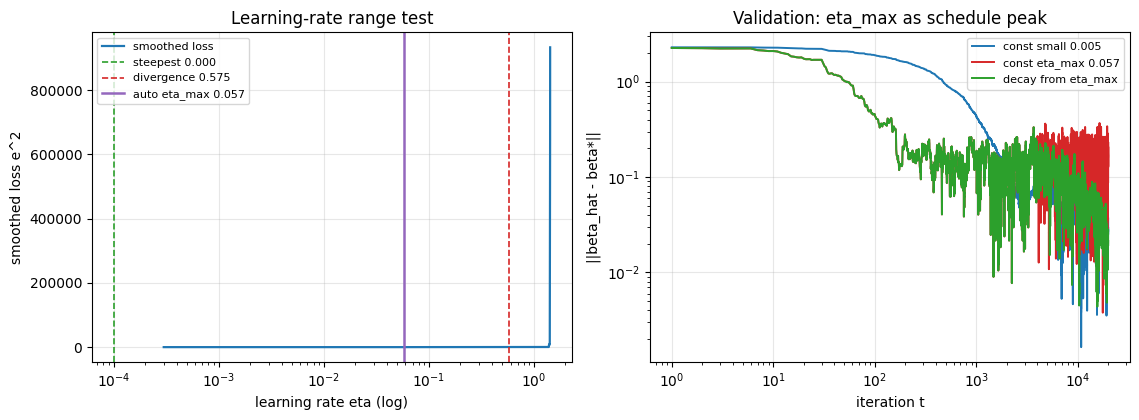

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.3))

# (left) LR range-test curve
m = finite & (etas > eta_min * 3)
ax[0].semilogx(etas[m], loss_curve[m], color='#1f77b4', lw=1.6, label='smoothed loss')
ax[0].axvline(eta_steep, color='#2ca02c', ls='--', lw=1.2, label=f'steepest {eta_steep:.3f}')
ax[0].axvline(eta_div,   color='#d62728', ls='--', lw=1.2, label=f'divergence {eta_div:.3f}')
ax[0].axvline(eta_max,   color='#9467bd', ls='-',  lw=1.8, label=f'auto eta_max {eta_max:.3f}')
ax[0].set_xlabel('learning rate eta (log)'); ax[0].set_ylabel('smoothed loss e^2')
ax[0].set_title('Learning-rate range test'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

# (right) validation convergence: small / const-eta_max / decay-from-eta_max
tt = np.arange(1, len(y_v) + 1)
cols = {'const small 0.005': '#1f77b4', f'const eta_max {eta_max:.3f}': '#d62728',
        'decay from eta_max': '#2ca02c'}
for k, e in runs.items():
    ax[1].loglog(tt, e, color=cols[k], lw=1.4, label=k)
ax[1].set_xlabel('iteration t'); ax[1].set_ylabel('||beta_hat - beta*||')
ax[1].set_title('Validation: eta_max as schedule peak'); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()


## 4. 결과 해석

한 번의 지수 스윕이 *loss-vs-$\eta$* 곡선의 네 국면(평탄·급강하·최소·발산)을 그대로 재현했다.

1. **평탄 구간**($\eta\lesssim$ 급강하점): 스텝이 너무 작아 손실이 초기값 근처에 머문다 — 편향(과도구간) 지배.
2. **급강하 어깨**(초록 점선): $d\mathcal L/d\log\eta$ 가 가장 가파른 곳. 유효 학습이 시작되는 지점으로, "가장 큰 안전한 스텝"의 하한을 알려준다.
3. **발산점**(빨강 점선): 이 $\eta$ 를 넘으면 잡음/불안정이 지배해 손실이 폭발한다(분산 지배). 자동 규칙은 발산 직전 한 자릿수 아래를 **안정 상한 $\eta_{\max}=\eta_{\text{div}}/10$**(보라 실선)으로 잡는다.
4. **핵심 통찰 — 산출물은 "상수율"이 아니라 "$\eta_{\max}$"**: 정상 스트림에서 tail 오차(잡음 바닥)는 $\propto\sqrt\eta$ 라 *작을수록* 낮다. 그래서 표에서 상수 $\eta_{\max}$ 는 빠르지만(steps↓) 바닥이 높고(tail↑), 상수 $0.005$ 는 바닥은 낮지만 느리다(steps↑). 어느 상수도 둘을 동시에 못 준다.
5. **검증(우) — $\eta_{\max}$ 를 §14.9 감쇠 스케줄의 peak 로**: `decay from eta_max`(초록)는 초반엔 $\eta_{\max}$ 로 **빠르게 하강**하고 이후 계단 감쇠로 **낮은 바닥**에 도달한다 — 표에서 *steps-to-threshold 는 상수 $\eta_{\max}$ 만큼 빠르면서*, *tail 은 작은 상수만큼 낮다*. 범위 탐색이 자동으로 찾아준 $\eta_{\max}$ 가 스케줄의 안전한 시작점을 정해 준 결과다.

> **결론**: 학습률 범위 탐색의 진짜 산출물은 **안정 상한 $\eta_{\max}$** 이며, 이를 §14.9 감쇠 스케줄의 peak 로 쓰면 단 한 번의 스윕으로 **빠른 하강과 낮은 바닥을 동시에** 얻는다.

**다음 문제로**: LR 파인더는 *정상* 스트림에서 좋은 $\eta_{\max}$ 하나를 준다. 그러나 분포가 드리프트하면 최적 $\eta$ 도 시간에 따라 변한다. Problem 2 는 학습률을 **온라인으로 진화**시키는 Population-Based Training 으로 넘어간다.
